# Week 7 (Day 26) — Live Coding 02
## Data Augmentation + Optimization Tricks (Transfer Learning)

Goal: improve generalization and training stability by systematically comparing:
- **augmentation strategies** (none vs light vs strong)
- **optimizers** (Adam, SGD+momentum, RMSprop)
- **learning-rate dynamics** (with `ReduceLROnPlateau`)
- **training speed** and validation/test performance

In [1]:
# Setup

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

TF_AVAILABLE = True
try:
    import tensorflow as tf
    import tensorflow_datasets as tfds
except Exception as e:
    TF_AVAILABLE = False
    TF_IMPORT_ERROR = e

if TF_AVAILABLE:
    from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

    IMG_SIZE = (160, 160)
    BATCH_SIZE = 32
    SEED = 42
    AUTOTUNE = tf.data.AUTOTUNE

    tf.random.set_seed(SEED)
    np.random.seed(SEED)

    print("TensorFlow:", tf.__version__)
    print("GPU available:", bool(tf.config.list_physical_devices("GPU")))
else:
    print("TensorFlow/TFDS not available in this environment.")
    print(f"Reason: {type(TF_IMPORT_ERROR).__name__}: {TF_IMPORT_ERROR}")
    print("Tip: run this notebook in Google Colab for Week 7 transfer learning labs.")

TensorFlow: 2.19.0
GPU available: True


In [2]:
if not TF_AVAILABLE:
    print("Skipping dataset loading because TensorFlow is unavailable.")
else:
    # Load TFDS dataset (train/val/test)
    (train_raw, val_raw, test_raw), ds_info = tfds.load(
        "cats_vs_dogs",
        split=["train[:70%]", "train[70%:85%]", "train[85%:]"],
        as_supervised=True,
        with_info=True,
    )

    print(ds_info)

    # Optional sample caps for faster live sessions
    MAX_TRAIN = 5000
    MAX_VAL = 1200
    MAX_TEST = 1200

    def resize_only(image, label):
        image = tf.image.resize(image, IMG_SIZE)
        image = tf.cast(image, tf.float32)
        return image, tf.cast(label, tf.int32)

    def prepare(ds, training=False, max_samples=None):
        if max_samples is not None:
            ds = ds.take(max_samples)
        if training:
            ds = ds.shuffle(1500, seed=SEED, reshuffle_each_iteration=True)
        ds = ds.map(resize_only, num_parallel_calls=AUTOTUNE)
        ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
        return ds

    train_ds = prepare(train_raw, training=True, max_samples=MAX_TRAIN)
    val_ds = prepare(val_raw, training=False, max_samples=MAX_VAL)
    test_ds = prepare(test_raw, training=False, max_samples=MAX_TEST)

    print("Datasets ready: train/val/test")

tfds.core.DatasetInfo(
    name='cats_vs_dogs',
    full_name='cats_vs_dogs/4.0.1',
    description="""
    A large set of images of cats and dogs. There are 1738 corrupted images that are dropped.
    """,
    homepage='https://www.microsoft.com/en-us/download/details.aspx?id=54765',
    data_dir='/root/tensorflow_datasets/cats_vs_dogs/4.0.1',
    file_format=tfrecord,
    download_size=786.67 MiB,
    dataset_size=1.04 GiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'image/filename': Text(shape=(), dtype=string),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=2),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=23262, num_shards=16>,
    },
    citation="""@Inproceedings (Conference){asirra-a-captcha-that-exploits-interest-aligned-manual-image-categorization,
    author = {Elson, Jeremy and Douceur, Jo

## Build augmentation policies and visualize examples

We define 3 policies and then compare them in training:
- `none`: no augmentation
- `light`: flip + small rotation/zoom
- `strong`: light + contrast + translation

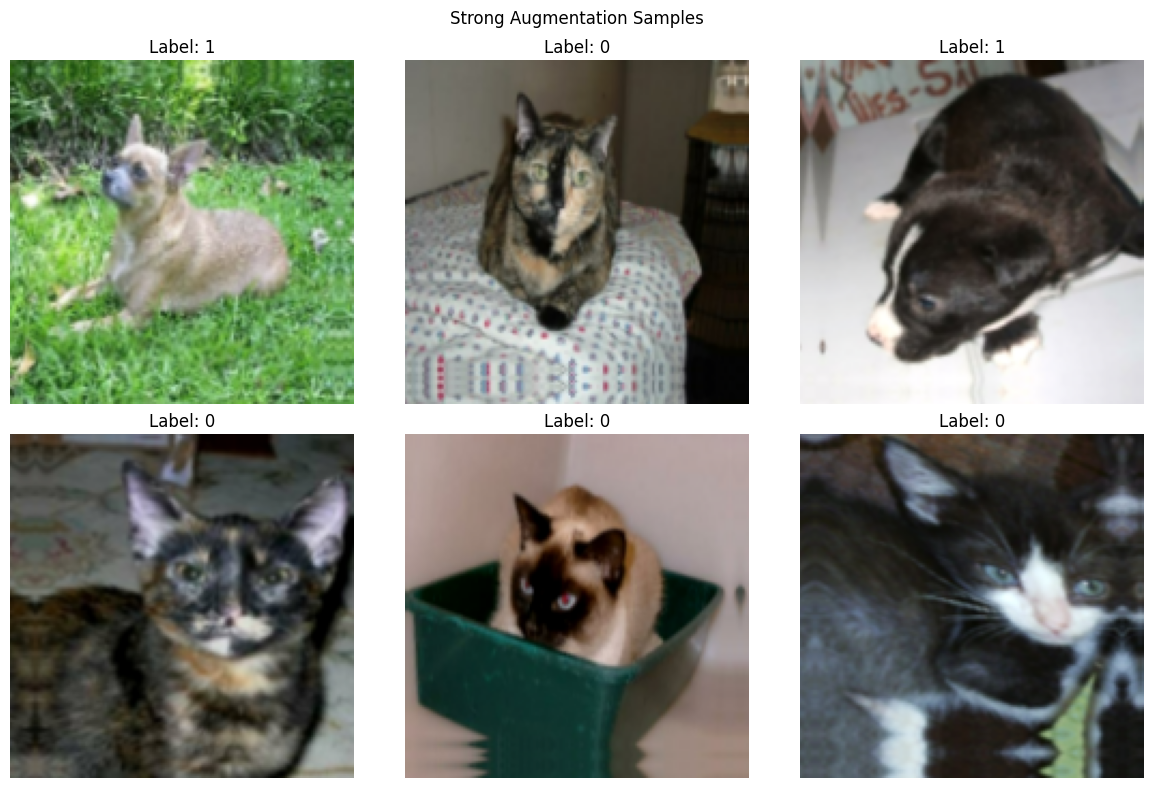

In [3]:
if not TF_AVAILABLE:
    print("Skipping augmentation setup because TensorFlow is unavailable.")
else:
    AUG_POLICIES = {
        "none": tf.keras.Sequential(
            [tf.keras.layers.Lambda(lambda x: x)],
            name="aug_none",
        ),
        "light": tf.keras.Sequential(
            [
                tf.keras.layers.RandomFlip("horizontal"),
                tf.keras.layers.RandomRotation(0.05),
                tf.keras.layers.RandomZoom(0.10),
            ],
            name="aug_light",
        ),
        "strong": tf.keras.Sequential(
            [
                tf.keras.layers.RandomFlip("horizontal"),
                tf.keras.layers.RandomRotation(0.08),
                tf.keras.layers.RandomZoom(0.15),
                tf.keras.layers.RandomContrast(0.15),
                tf.keras.layers.RandomTranslation(0.08, 0.08),
            ],
            name="aug_strong",
        ),
    }

    # Quick visualization on one training batch
    sample_images, sample_labels = next(iter(train_ds))
    plt.figure(figsize=(12, 8))
    for i in range(6):
        plt.subplot(2, 3, i + 1)
        aug_img = AUG_POLICIES["strong"](sample_images[i:i+1], training=True)[0]
        plt.imshow(tf.cast(tf.clip_by_value(aug_img, 0, 255), tf.uint8))
        plt.title(f"Label: {int(sample_labels[i])}")
        plt.axis("off")
    plt.suptitle("Strong Augmentation Samples")
    plt.tight_layout()
    plt.show()

In [4]:
if not TF_AVAILABLE:
    print("Skipping model utilities because TensorFlow is unavailable.")
else:
    class LrTracker(tf.keras.callbacks.Callback):
        def on_train_begin(self, logs=None):
            self.lr_history = []

        def on_epoch_end(self, epoch, logs=None):
            lr = float(tf.keras.backend.get_value(self.model.optimizer.learning_rate))
            self.lr_history.append(lr)


    def make_optimizer(name, lr):
        if name == "adam":
            return tf.keras.optimizers.Adam(learning_rate=lr)
        if name == "sgd":
            return tf.keras.optimizers.SGD(learning_rate=lr, momentum=0.9)
        if name == "rmsprop":
            return tf.keras.optimizers.RMSprop(learning_rate=lr)
        raise ValueError("optimizer name must be one of: adam, sgd, rmsprop")


    def build_model(augmentation_layer, optimizer_name="adam", lr=1e-3, dropout=0.3):
        base = tf.keras.applications.EfficientNetB0(
            include_top=False,
            weights="imagenet",
            input_shape=IMG_SIZE + (3,),
        )
        base.trainable = False
        preprocess_input = tf.keras.applications.efficientnet.preprocess_input

        inputs = tf.keras.layers.Input(shape=IMG_SIZE + (3,))
        x = augmentation_layer(inputs, training=True)
        x = tf.keras.layers.Lambda(preprocess_input)(x)
        x = base(x, training=False)
        x = tf.keras.layers.GlobalAveragePooling2D()(x)
        x = tf.keras.layers.Dropout(dropout)(x)
        outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
        model = tf.keras.Model(inputs, outputs)

        model.compile(
            optimizer=make_optimizer(optimizer_name, lr),
            loss="binary_crossentropy",
            metrics=["accuracy"],
        )
        return model


=== Running A_none_adam | aug=none | opt=adam | lr=0.001 ===
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 71s 252ms/step - accuracy: 0.8613 - loss: 0.3456 - val_accuracy: 0.9817 - val_loss: 0.0824 - learning_rate: 0.0010
Epoch 2/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - accuracy: 0.9780 - loss: 0.0815 - val_accuracy: 0.9867 - val_loss: 0.0559 - learning_rate: 0.0010
Epoch 3/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 44ms/step - accuracy: 0.9804 - loss: 0.0601 - val_accuracy: 0.9900 - val_loss: 0.0477 - learning_rate: 0.0010
Epoch 4/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 48ms/step - accuracy: 0.9880 - loss: 0.0495 - val_accuracy: 0.9883 - val_loss: 0.0431 - learning_rate: 0.0010
Epoch 5/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.9866 - loss: 0.0441 - val_accuracy: 0.9900 - val_loss: 0.0401 - learning_rate: 0.0010
Epoch 6/6
157/157 ━━━━━━━━━━━━━━━━━━━━ 9s 52ms/step - accuracy: 0.9878 - loss: 0.0400 - val_accuracy: 0.9900 - val_loss: 0.0

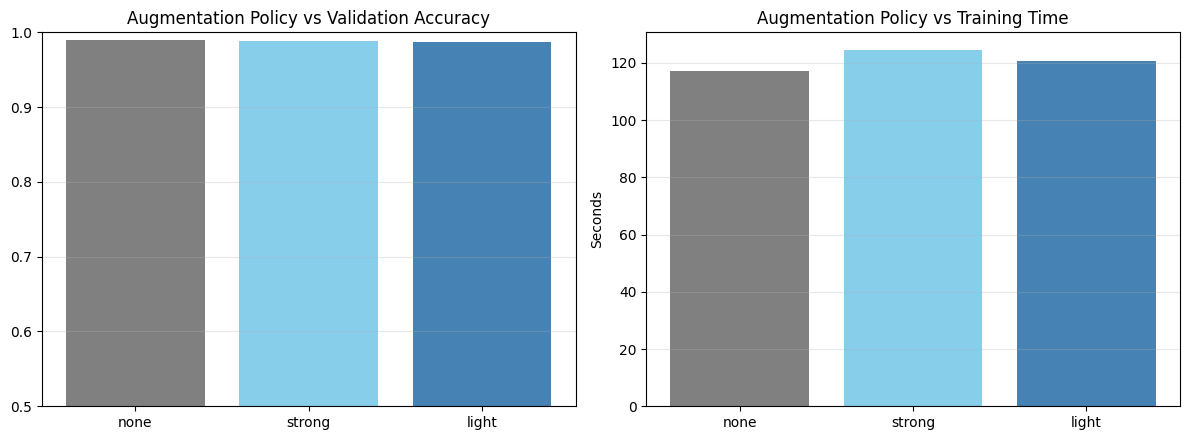

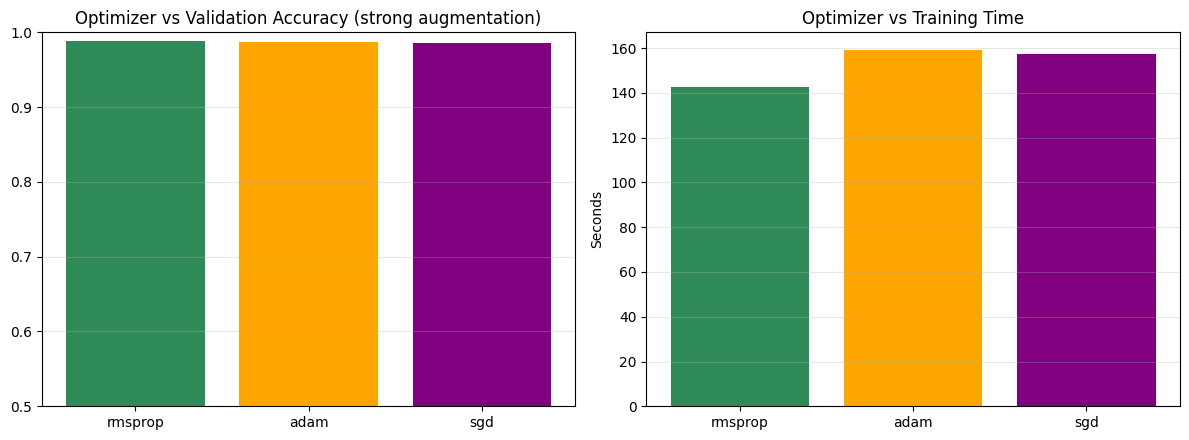

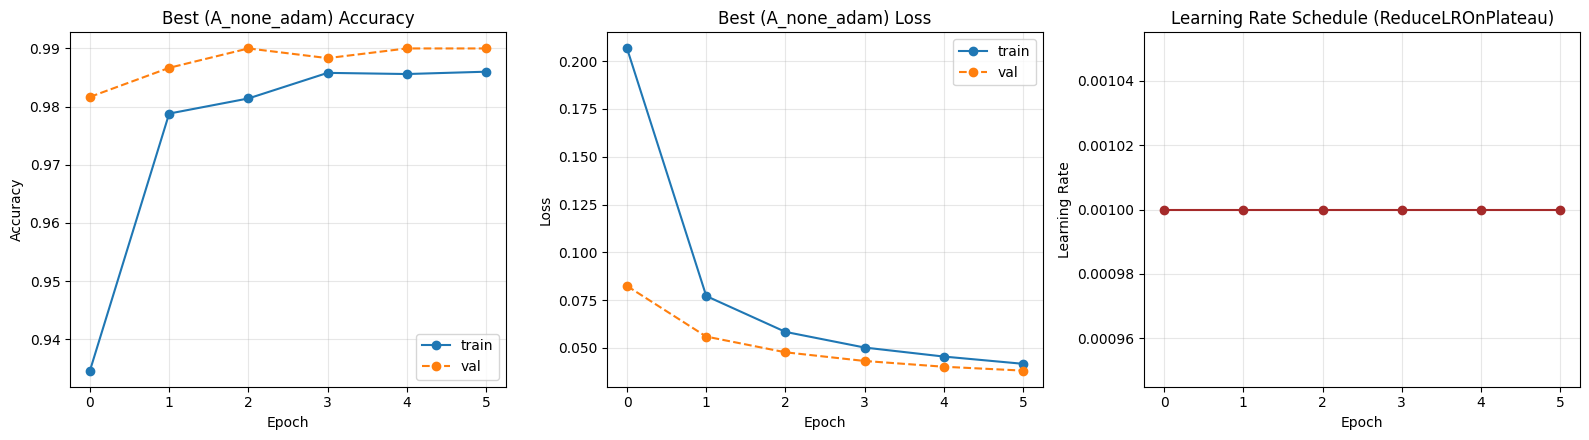


Best experiment on validation: A_none_adam
              precision    recall  f1-score   support

         cat       0.98      0.99      0.98       591
         dog       0.99      0.98      0.99       609

    accuracy                           0.98      1200
   macro avg       0.98      0.99      0.98      1200
weighted avg       0.99      0.98      0.99      1200



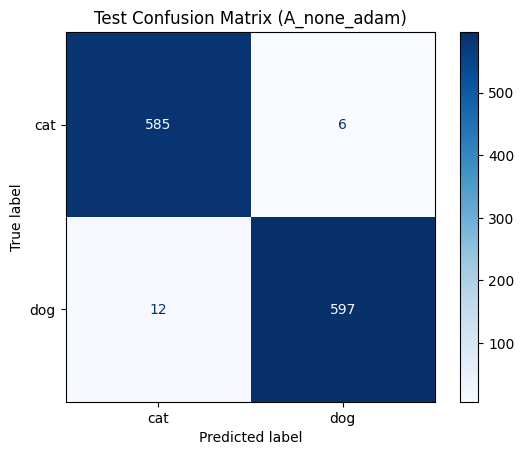

In [5]:
if not TF_AVAILABLE:
    print("Skipping experiments because TensorFlow is unavailable.")
else:
    EPOCHS = 6

    # Phase A: augmentation comparison (fixed optimizer)
    aug_configs = [
        {"exp": "A_none_adam", "aug": "none", "opt": "adam", "lr": 1e-3},
        {"exp": "A_light_adam", "aug": "light", "opt": "adam", "lr": 1e-3},
        {"exp": "A_strong_adam", "aug": "strong", "opt": "adam", "lr": 1e-3},
    ]

    # Phase B: optimizer comparison (fixed augmentation)
    opt_configs = [
        {"exp": "B_strong_adam", "aug": "strong", "opt": "adam", "lr": 1e-3},
        {"exp": "B_strong_sgd", "aug": "strong", "opt": "sgd", "lr": 5e-3},
        {"exp": "B_strong_rms", "aug": "strong", "opt": "rmsprop", "lr": 1e-3},
    ]

    all_configs = aug_configs + opt_configs
    results = []
    histories = {}
    best_model_by_exp = {}

    for cfg in all_configs:
        print(f"\n=== Running {cfg['exp']} | aug={cfg['aug']} | opt={cfg['opt']} | lr={cfg['lr']} ===")
        model = build_model(
            augmentation_layer=AUG_POLICIES[cfg["aug"]],
            optimizer_name=cfg["opt"],
            lr=cfg["lr"],
            dropout=0.3,
        )

        lr_tracker = LrTracker()
        callbacks = [
            tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", patience=1, factor=0.4, min_lr=1e-6),
            lr_tracker,
        ]

        t0 = time.perf_counter()
        hist = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS,
            callbacks=callbacks,
            verbose=1,
        )
        elapsed = time.perf_counter() - t0

        val_loss, val_acc = model.evaluate(val_ds, verbose=0)
        test_loss, test_acc = model.evaluate(test_ds, verbose=0)

        histories[cfg["exp"]] = {
            "history": hist.history,
            "lr": lr_tracker.lr_history,
            "cfg": cfg,
        }
        best_model_by_exp[cfg["exp"]] = model

        results.append(
            {
                "Experiment": cfg["exp"],
                "Augmentation": cfg["aug"],
                "Optimizer": cfg["opt"],
                "LR": cfg["lr"],
                "Val Accuracy": float(val_acc),
                "Test Accuracy": float(test_acc),
                "Val Loss": float(val_loss),
                "Time (s)": float(elapsed),
            }
        )

    results_df = pd.DataFrame(results).sort_values("Val Accuracy", ascending=False).reset_index(drop=True)
    print("\n=== Experiment Summary ===")
    print(results_df.to_string(index=False))

    # -------- Visualize augmentation effect --------
    aug_df = results_df[results_df["Experiment"].str.startswith("A_")].sort_values("Val Accuracy", ascending=False)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].bar(aug_df["Augmentation"], aug_df["Val Accuracy"], color=["gray", "skyblue", "steelblue"])
    axes[0].set_title("Augmentation Policy vs Validation Accuracy")
    axes[0].set_ylim(0.5, 1.0)
    axes[0].grid(axis="y", alpha=0.3)

    axes[1].bar(aug_df["Augmentation"], aug_df["Time (s)"], color=["gray", "skyblue", "steelblue"])
    axes[1].set_title("Augmentation Policy vs Training Time")
    axes[1].set_ylabel("Seconds")
    axes[1].grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # -------- Visualize optimizer effect --------
    opt_df = results_df[results_df["Experiment"].str.startswith("B_")].sort_values("Val Accuracy", ascending=False)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
    axes[0].bar(opt_df["Optimizer"], opt_df["Val Accuracy"], color=["seagreen", "orange", "purple"])
    axes[0].set_title("Optimizer vs Validation Accuracy (strong augmentation)")
    axes[0].set_ylim(0.5, 1.0)
    axes[0].grid(axis="y", alpha=0.3)

    axes[1].bar(opt_df["Optimizer"], opt_df["Time (s)"], color=["seagreen", "orange", "purple"])
    axes[1].set_title("Optimizer vs Training Time")
    axes[1].set_ylabel("Seconds")
    axes[1].grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

    # -------- Learning curves for best experiment --------
    best_exp = results_df.iloc[0]["Experiment"]
    best_hist = histories[best_exp]
    h = best_hist["history"]

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
    axes[0].plot(h["accuracy"], marker="o", label="train")
    axes[0].plot(h["val_accuracy"], marker="o", linestyle="--", label="val")
    axes[0].set_title(f"Best ({best_exp}) Accuracy")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].grid(alpha=0.3)
    axes[0].legend()

    axes[1].plot(h["loss"], marker="o", label="train")
    axes[1].plot(h["val_loss"], marker="o", linestyle="--", label="val")
    axes[1].set_title(f"Best ({best_exp}) Loss")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].grid(alpha=0.3)
    axes[1].legend()

    axes[2].plot(best_hist["lr"], marker="o", color="brown")
    axes[2].set_title("Learning Rate Schedule (ReduceLROnPlateau)")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Learning Rate")
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    # -------- Test confusion matrix for best model --------
    best_model = best_model_by_exp[best_exp]
    y_true, y_prob = [], []
    for xb, yb in test_ds:
        probs = best_model.predict(xb, verbose=0).ravel()
        y_prob.extend(probs.tolist())
        y_true.extend(yb.numpy().tolist())

    y_true = np.array(y_true)
    y_pred = (np.array(y_prob) >= 0.5).astype(int)

    print("\nBest experiment on validation:", best_exp)
    print(classification_report(y_true, y_pred, target_names=["cat", "dog"]))

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["cat", "dog"]).plot(cmap="Blues")
    plt.title(f"Test Confusion Matrix ({best_exp})")
    plt.show()